# Chapter 5: Clustering

**Book:** *Hands-On Unsupervised Learning Using Python* — Ankur A. Patel (O'Reilly, 2019)  
**Audience:** Beginners  
**Goal:** Learn unsupervised **clustering** algorithms using the MNIST (Modified National Institute of Standards and Technology) digits dataset — k-Means, hierarchical clustering, DBSCAN (Density-Based Spatial Clustering of Applications with Noise), and HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise).

---

## What you will learn

1. What clustering is and how it differs from classification
2. Prepare MNIST image data and apply PCA (Principal Component Analysis) before clustering
3. **k-Means:** inertia (Within-Cluster Sum of Squares), choosing k, cluster accuracy vs true digit labels
4. How k-Means accuracy changes with number of PCA (Principal Component Analysis) components and original dimensions
5. **Hierarchical clustering:** dendrogram (cluster tree), agglomerative merging, evaluation
6. **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):** density-based clusters and noise points
7. **HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise):** optional extension when library is installed
8. Compare clustering algorithms on the same dataset


## Setup — run this cell first

| Library | Purpose |
|---------|--------|
| **NumPy (Numerical Python)** | Arrays and math |
| **Pandas (Python Data Analysis Library)** | DataFrames (two-dimensional labeled data tables) |
| **Matplotlib (Mathematical Plotting Library)** | Plots — inertia curves, dendrograms, sample digits |
| **scikit-learn (Scientific Kit for Learning)** | PCA (Principal Component Analysis), k-Means, DBSCAN, AgglomerativeClustering |
| **SciPy (Scientific Python)** | Dendrogram plotting for hierarchical clustering |
| **hdbscan** *(optional)* | HDBSCAN algorithm — installed separately if needed |


In [1]:
# Import warnings module so we can hide non-critical messages during demos
import warnings

# Hide sklearn (scikit-learn)/matplotlib warnings to keep notebook output clean for beginners
warnings.filterwarnings("ignore")

# Import NumPy (Numerical Python) for fast numerical operations on arrays
import numpy as np

# Import Pandas (Python Data Analysis Library) for working with labeled tables (DataFrames)
import pandas as pd

# Import Matplotlib (Mathematical Plotting Library) for creating charts
import matplotlib.pyplot as plt

# Import MNIST (Modified National Institute of Standards and Technology) loader and digit fallback
from sklearn.datasets import fetch_openml, load_digits

# Import PCA (Principal Component Analysis) for dimensionality reduction before clustering
from sklearn.decomposition import PCA

# Import StandardScaler to put pixel features on comparable scale
from sklearn.preprocessing import StandardScaler

# Import clustering algorithms covered in Chapter 5
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Import SciPy (Scientific Python) hierarchy tools for dendrogram visualization
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Import silhouette score to measure cluster separation (optional evaluation metric)
from sklearn.metrics import silhouette_score

# Try to import HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)
try:

    import hdbscan

    HDBSCAN_AVAILABLE = True

except ImportError:

    HDBSCAN_AVAILABLE = False

    print("Note: hdbscan not installed — HDBSCAN section will use instructions only. pip install hdbscan")

# Import display() for rich table output inside Jupyter (Julia, Python, and R notebook environment)
from IPython.display import display

# Confirm setup completed without errors
print("Libraries loaded successfully.")


Note: hdbscan not installed — HDBSCAN section will use instructions only. pip install hdbscan
Libraries loaded successfully.


---

## Libraries Imported in This Notebook

| Library | What it does | Why we use it here |
|---------|--------------|-------------------|
| **NumPy (Numerical Python)** (`np`) | Fast math on arrays | Store MNIST pixels and cluster labels |
| **Pandas (Python Data Analysis Library)** (`pd`) | Spreadsheet-like DataFrames | Organize cluster results and accuracy tables |
| **Matplotlib (Mathematical Plotting Library)** (`plt`) | Charts and plots | Inertia curves, dendrograms, digit images |
| **sklearn.datasets** | Built-in datasets | Load MNIST (Modified National Institute of Standards and Technology) digits |
| **sklearn.decomposition.PCA** | Linear dimensionality reduction | Compress 784 pixels to fewer components for faster clustering |
| **sklearn.preprocessing.StandardScaler** | Feature scaling | Normalize pixel values before PCA (Principal Component Analysis) |
| **sklearn.cluster.KMeans** | Centroid-based clustering | Partition digits into k groups |
| **sklearn.cluster.AgglomerativeClustering** | Bottom-up hierarchical clustering | Alternative to fastcluster used in the book |
| **sklearn.cluster.DBSCAN** | Density-based clustering | Find dense digit regions; mark outliers as noise (-1) |
| **scipy.cluster.hierarchy** | Linkage and dendrogram | Visualize hierarchical merge tree |
| **hdbscan** *(optional)* | Hierarchical DBSCAN | Multi-scale density clustering from Chapter 5 |


---

## Algorithms Used in This Notebook

### 1. k-Means (`KMeans`)
- **Type:** Centroid-based (center-based) partitioning clustering
- **Finds:** k groups by placing centroids (cluster centers) and assigning each point to the nearest centroid
- **Key hyperparameters:** `n_clusters` (k), `n_init` (restart count), `max_iter`, `tol` (tolerance)
- **Key metric — Inertia (Within-Cluster Sum of Squares, WCSS):** Sum of squared distances from points to their centroid; lower is tighter clusters

### 2. Agglomerative Hierarchical Clustering
- **Type:** Bottom-up hierarchical clustering
- **Finds:** Nested clusters by repeatedly merging the two closest groups
- **Dendrogram (hierarchical cluster tree):** Diagram showing merge order and distance
- **Book note:** Author uses `fastcluster`; we use SciPy (Scientific Python) `linkage` + `fcluster` for portability

### 3. DBSCAN (`DBSCAN`)
- **Type:** Density-Based Spatial Clustering of Applications with Noise
- **Finds:** Dense regions separated by sparse areas; points in sparse regions labeled **-1 (noise)**
- **Key hyperparameters:** `eps` (neighborhood radius), `min_samples` (minimum neighbors to form a core point)

### 4. HDBSCAN (`hdbscan.HDBSCAN`) — optional
- **Type:** Hierarchical Density-Based Spatial Clustering of Applications with Noise
- **Finds:** Clusters of varying density without fixing `eps` manually
- **Requires:** `pip install hdbscan`

### Evaluation note (important for beginners)

Clustering is **unsupervised** — algorithms never see digit labels during training. We use true labels **only to measure how well clusters align with digits** (same method as the book's `analyzeCluster` function). This is for learning and comparison, not for production evaluation.


---

## 1. What Is Clustering?

**Clustering** groups similar data points together **without** using labels during training.

| | Classification (supervised) | Clustering (unsupervised) |
|--|---------------------------|---------------------------|
| **Labels used in training?** | Yes | No |
| **Goal** | Predict class for new points | Discover natural groups |
| **Chapter 5 example** | N/A — we evaluate clusters against labels afterward | Group MNIST digit images by pixel similarity |

**Key terms:**

| Term | Meaning |
|------|--------|
| **Cluster** | A group of similar points |
| **Centroid (cluster center)** | Mean position of a k-Means cluster |
| **Inertia (WCSS)** | k-Means tightness measure — lower means more compact clusters |
| **Dendrogram** | Tree diagram of hierarchical merges |
| **Noise point** | Outlier not assigned to any DBSCAN cluster (label -1) |


---

## 2. MNIST (Modified National Institute of Standards and Technology) Data Preparation

The book uses **MNIST handwritten digits**: 28×28 grayscale images (784 pixels per image), digits 0–9.

We load a **subset** (8,000 training images) so the notebook runs quickly on a laptop. If download fails, we fall back to `load_digits` (smaller 8×8 digits).


In [2]:
# Set random seed so subsampling and clustering are reproducible
RANDOM_STATE = 2018

# Number of MNIST samples to use (subset for faster teaching demos)
N_SAMPLES = 8000

# Try to download MNIST 784 features from OpenML (online ML repository)
try:

    print("Loading MNIST (Modified National Institute of Standards and Technology) from OpenML — may take a minute...")

    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")

    X_full = mnist.data.astype(np.float64)

    y_full = mnist.target.astype(int)

    rng = np.random.RandomState(RANDOM_STATE)

    idx = rng.choice(len(y_full), size=N_SAMPLES, replace=False)

    X_raw = X_full[idx]

    y = y_full[idx]

    DATA_SOURCE = "MNIST 784 (subset)"

except Exception as e:

    print(f"MNIST download failed ({e}). Using sklearn load_digits fallback.")

    digits = load_digits()

    X_raw = digits.data.astype(np.float64)

    y = digits.target.astype(int)

    DATA_SOURCE = "load_digits (8x8 fallback)"

# Report dataset shape: rows = images, columns = pixels
print(f"Data source: {DATA_SOURCE}")

print(f"X shape: {X_raw.shape}  |  unique digit labels: {np.unique(y)}")

# Show class balance — digits are roughly balanced in MNIST
print("Samples per digit:")

print(pd.Series(y).value_counts().sort_index())


Loading MNIST (Modified National Institute of Standards and Technology) from OpenML — may take a minute...
Data source: MNIST 784 (subset)
X shape: (8000, 784)  |  unique digit labels: [0 1 2 3 4 5 6 7 8 9]
Samples per digit:
0    844
1    857
2    827
3    808
4    769
5    687
6    778
7    859
8    755
9    816
Name: count, dtype: int64


In [3]:
# Scale pixel values so PCA (Principal Component Analysis) is not dominated by magnitude
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_raw)

# Fit PCA (Principal Component Analysis) — keep enough components for clustering experiments
N_PCA = 100

pca = PCA(n_components=N_PCA, random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)

# Build pandas DataFrame (two-dimensional labeled data table) with PCA columns like the book
pca_cols = [f"PC{i+1}" for i in range(N_PCA)]

X_train_PCA = pd.DataFrame(X_pca, columns=pca_cols)

y_train = pd.Series(y, name="trueLabel")

# Show variance explained by first components
print(f"PCA (Principal Component Analysis) reduced {X_raw.shape[1]} dims → {N_PCA} dims")

print(f"Variance retained (first {N_PCA} components): {pca.explained_variance_ratio_.sum():.1%}")

display(X_train_PCA.head())


PCA (Principal Component Analysis) reduced 784 dims → 100 dims
Variance retained (first 100 components): 76.2%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC91,PC92,PC93,PC94,PC95,PC96,PC97,PC98,PC99,PC100
0,5.272536,-8.530883,1.188167,-1.804227,-5.240573,4.301417,0.805467,-1.527190,-2.116974,-3.049584,...,-0.147116,-0.984226,0.194912,-0.496308,-0.517849,-0.580991,0.980619,-0.966038,-0.653590,1.272320
1,3.845586,-2.129127,3.636924,-2.434205,-1.963608,3.364207,0.254149,0.762394,0.477677,2.727795,...,-1.649828,-1.334428,1.103343,0.150335,0.926424,1.065927,0.739638,-0.152762,-0.273505,0.969937
2,-5.481893,0.258605,-8.713209,-1.382424,4.125852,5.638417,-7.084615,2.485660,2.573444,-1.910382,...,0.367730,-0.457136,-0.232579,-0.095850,-0.443125,0.641870,-0.812782,0.033388,0.476441,1.962041
3,-3.250438,3.696537,-6.747715,0.085607,-4.998333,1.128145,-0.679940,-5.504081,4.028692,1.172999,...,-0.175636,-0.886404,-0.103548,-0.424391,0.674580,-0.612522,-0.219783,0.032213,-1.304634,0.550872
4,0.708683,6.101156,18.736909,6.739744,4.573317,9.560460,-1.138919,3.891008,-4.414420,8.789421,...,2.691256,0.037056,1.127560,-1.109819,-0.974828,-0.302635,-0.591641,-2.068636,-1.541701,0.103810


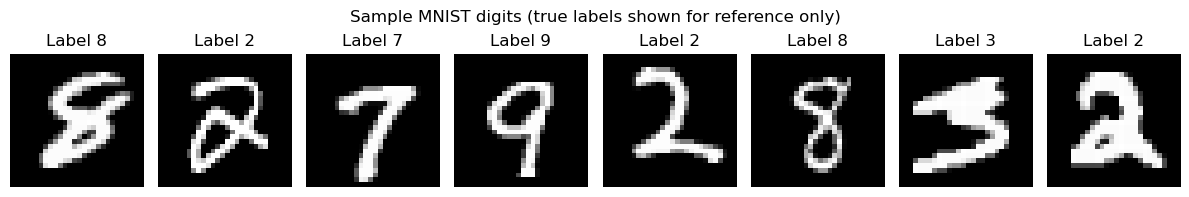

In [4]:
# Visualize a few original digit images to connect pixels to clusters
n_show = 8

fig, axes = plt.subplots(1, n_show, figsize=(12, 2))

side = int(np.sqrt(X_raw.shape[1]))

for ax, i in zip(axes, range(n_show)):

    ax.imshow(X_raw[i].reshape(side, side), cmap="gray")

    ax.set_title(f"Label {y[i]}")

    ax.axis("off")

plt.suptitle("Sample MNIST digits (true labels shown for reference only)")

plt.tight_layout()

plt.show()


---

## 3. Helper — Evaluate Clusters Against True Labels

The book defines `analyzeCluster` to measure **cluster purity**: for each cluster, assign the most frequent true digit and count correct assignments.

> **Reminder:** True labels are used **only for evaluation**, not during clustering.


In [5]:
# Define analyzeCluster — same logic as the book's Chapter 5 helper
def analyzeCluster(clusterDF, labelsDF):

    # Count how many points fall in each cluster
    countByCluster = pd.DataFrame(clusterDF["cluster"].value_counts()).reset_index()

    countByCluster.columns = ["cluster", "clusterCount"]

    # Combine true digit labels with cluster assignments
    preds = pd.concat([labelsDF, clusterDF], axis=1)

    preds.columns = ["trueLabel", "cluster"]

    # For each cluster, count how many points match the most frequent digit in that cluster
    countMostFreq = preds.groupby("cluster").agg(lambda x: x.value_counts().iloc[0])

    countMostFreq = countMostFreq.reset_index()

    countMostFreq.columns = ["cluster", "countMostFrequent"]

    # Merge counts to compute accuracy per cluster
    accuracyDF = countMostFreq.merge(countByCluster, on="cluster")

    overallAccuracy = accuracyDF["countMostFrequent"].sum() / accuracyDF["clusterCount"].sum()

    accuracyByLabel = accuracyDF["countMostFrequent"] / accuracyDF["clusterCount"]

    return countByCluster, countMostFreq, accuracyDF, overallAccuracy, accuracyByLabel


---

## 4. k-Means Clustering

### 4.1 Inertia (Within-Cluster Sum of Squares) vs Number of Clusters k

**Elbow method:** Plot inertia vs k — look for a bend ("elbow") where adding clusters helps less.


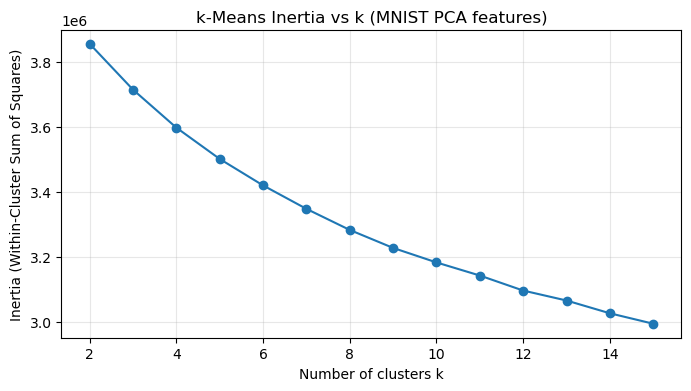

,k,inertia
0,2,3.856113e+06
1,3,3.715115e+06
2,4,3.598267e+06
3,5,3.502036e+06
4,6,3.420683e+06
5,7,3.348604e+06
6,8,3.283737e+06
7,9,3.228466e+06
8,10,3.183862e+06
9,11,3.143593e+06


In [6]:
# Sweep k from 2 to 15 and record k-Means inertia for each k
k_range = range(2, 16)

inertia_rows = []

for n_clusters in k_range:

    # Use first 100 PCA (Principal Component Analysis) components (book uses cutoff=99 → 100 dims)
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, max_iter=300, tol=1e-4, random_state=RANDOM_STATE)

    kmeans.fit(X_train_PCA.iloc[:, :100])

    inertia_rows.append({"k": n_clusters, "inertia": kmeans.inertia_})

inertia_df = pd.DataFrame(inertia_rows)

plt.figure(figsize=(8, 4))

plt.plot(inertia_df["k"], inertia_df["inertia"], marker="o")

plt.xlabel("Number of clusters k")

plt.ylabel("Inertia (Within-Cluster Sum of Squares)")

plt.title("k-Means Inertia vs k (MNIST PCA features)")

plt.grid(True, alpha=0.3)

plt.show()

display(inertia_df)


### 4.2 Clustering Accuracy vs k

For each k, we assign each cluster the **most common digit** and measure what fraction of points are correctly mapped.


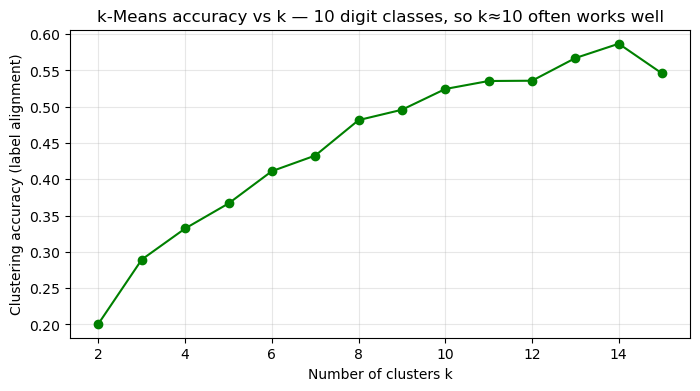

,k,overallAccuracy
0,2,0.201000
1,3,0.289500
2,4,0.332250
3,5,0.366750
4,6,0.411250
5,7,0.432750
6,8,0.481625
7,9,0.495875
8,10,0.524500
9,11,0.535500


In [7]:
# Measure clustering accuracy vs k using analyzeCluster helper
acc_rows = []

for n_clusters in k_range:

    kmeans = KMeans(n_clusters=n_clusters, n_init=10, max_iter=300, tol=1e-4, random_state=RANDOM_STATE)

    labels = kmeans.fit_predict(X_train_PCA.iloc[:, :100])

    clusterDF = pd.DataFrame({"cluster": labels}, index=y_train.index)

    _, _, _, overall_acc, _ = analyzeCluster(clusterDF, y_train)

    acc_rows.append({"k": n_clusters, "overallAccuracy": overall_acc})

acc_df = pd.DataFrame(acc_rows)

plt.figure(figsize=(8, 4))

plt.plot(acc_df["k"], acc_df["overallAccuracy"], marker="o", color="green")

plt.xlabel("Number of clusters k")

plt.ylabel("Clustering accuracy (label alignment)")

plt.title("k-Means accuracy vs k — 10 digit classes, so k≈10 often works well")

plt.grid(True, alpha=0.3)

plt.show()

display(acc_df)


### 4.3 Accuracy vs Number of PCA (Principal Component Analysis) Components

The book varies how many PCA dimensions are fed to k-Means. More components can capture detail but add noise and runtime.


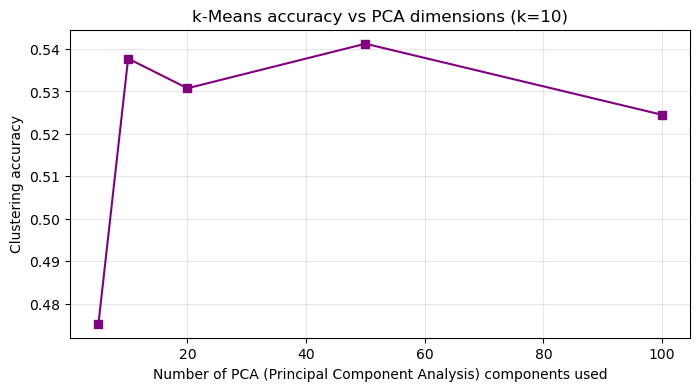

,n_components,overallAccuracy
0,5,0.47525
1,10,0.53775
2,20,0.53075
3,50,0.54125
4,100,0.52450


In [8]:
# Fix k=10 (one cluster per digit) and vary number of PCA components
n_clusters = 10

pca_counts = [5, 10, 20, 50, 100]

pca_acc_rows = []

for n_comp in pca_counts:

    kmeans = KMeans(n_clusters=n_clusters, n_init=10, max_iter=300, random_state=RANDOM_STATE)

    labels = kmeans.fit_predict(X_train_PCA.iloc[:, :n_comp])

    clusterDF = pd.DataFrame({"cluster": labels}, index=y_train.index)

    _, _, _, overall_acc, _ = analyzeCluster(clusterDF, y_train)

    pca_acc_rows.append({"n_components": n_comp, "overallAccuracy": overall_acc})

pca_acc_df = pd.DataFrame(pca_acc_rows)

plt.figure(figsize=(8, 4))

plt.plot(pca_acc_df["n_components"], pca_acc_df["overallAccuracy"], marker="s", color="purple")

plt.xlabel("Number of PCA (Principal Component Analysis) components used")

plt.ylabel("Clustering accuracy")

plt.title("k-Means accuracy vs PCA dimensions (k=10)")

plt.grid(True, alpha=0.3)

plt.show()

display(pca_acc_df)


### 4.4 k-Means on Original (Scaled) Pixel Dimensions

The book also clusters on raw MNIST pixels (not PCA-reduced). We use a **random subset of 100 pixels** when full 784-D is too slow on small machines.


In [9]:
# Use scaled original pixels — subsample 100 features if dimensionality is high
n_features_raw = min(100, X_scaled.shape[1])

rng = np.random.RandomState(RANDOM_STATE)

feat_idx = rng.choice(X_scaled.shape[1], size=n_features_raw, replace=False)

X_orig_subset = X_scaled[:, feat_idx]

kmeans_raw = KMeans(n_clusters=10, n_init=10, max_iter=300, random_state=RANDOM_STATE)

labels_raw = kmeans_raw.fit_predict(X_orig_subset)

clusterDF_raw = pd.DataFrame({"cluster": labels_raw}, index=y_train.index)

_, _, _, acc_raw, _ = analyzeCluster(clusterDF_raw, y_train)

print(f"k-Means on {n_features_raw} original scaled pixel features: accuracy = {acc_raw:.2%}")

print(f"Inertia (WCSS): {kmeans_raw.inertia_:.2f}")


k-Means on 100 original scaled pixel features: accuracy = 41.74%
Inertia (WCSS): 596329.98


---

## 5. Hierarchical Clustering

**Agglomerative hierarchical clustering** merges the closest clusters step by step. A **dendrogram (hierarchical cluster tree)** visualizes the merge history.


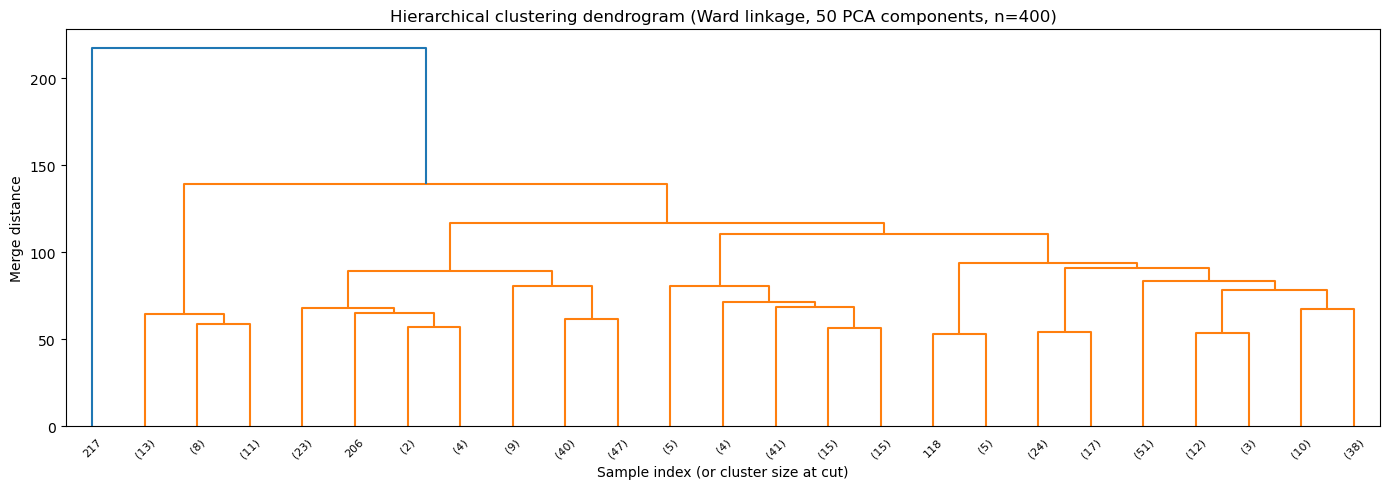

In [10]:
# Use a smaller subsample for dendrogram (linkage is O(n^2) memory/time)
N_DENDRO = 400

rng = np.random.RandomState(RANDOM_STATE)

d_idx = rng.choice(len(X_train_PCA), size=N_DENDRO, replace=False)

X_dendro = X_train_PCA.iloc[d_idx, :50].values

# Ward linkage minimizes variance when merging — common for Euclidean data
Z = linkage(X_dendro, method="ward")

plt.figure(figsize=(14, 5))

dendrogram(Z, truncate_mode="lastp", p=25, leaf_rotation=45, leaf_font_size=8)

plt.title("Hierarchical clustering dendrogram (Ward linkage, 50 PCA components, n=400)")

plt.xlabel("Sample index (or cluster size at cut)")

plt.ylabel("Merge distance")

plt.tight_layout()

plt.show()


In [11]:
# Cut dendrogram at distance threshold to form flat clusters (book uses fcluster)
distance_threshold = 50

hier_labels = fcluster(Z, t=distance_threshold, criterion="distance")

y_dendro = y_train.iloc[d_idx].values

clusterDF_hier = pd.DataFrame({"cluster": hier_labels}, index=d_idx)

labels_dendro = pd.Series(y_dendro, index=d_idx, name="trueLabel")

countByCluster, _, _, overall_acc_hier, acc_by = analyzeCluster(clusterDF_hier, labels_dendro)

print(f"Hierarchical clusters at distance={distance_threshold}: {len(np.unique(hier_labels))} groups")

print(f"Overall clustering accuracy: {overall_acc_hier:.2%}")

display(countByCluster.head(10))


Hierarchical clusters at distance=50: 26 groups
Overall clustering accuracy: 67.75%


,cluster,clusterCount
0,21,51
1,10,47
2,9,40
3,25,38
4,19,24
5,4,23
6,13,21
7,14,20
8,20,17
9,16,15


---

## 6. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN finds **dense regions** and marks sparse points as **noise (-1)**. It can discover non-round clusters but requires tuning `eps` and `min_samples`.


In [12]:
# Run DBSCAN on first 100 PCA components (same cutoff style as the book)
dbscan = DBSCAN(eps=3.0, min_samples=5, n_jobs=-1)

db_labels = dbscan.fit_predict(X_train_PCA.iloc[:, :100])

clusterDF_db = pd.DataFrame({"cluster": db_labels}, index=y_train.index)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)

n_noise = (db_labels == -1).sum()

print(f"DBSCAN found {n_clusters_db} clusters and {n_noise} noise points ({n_noise/len(db_labels):.1%})")

_, _, _, overall_acc_db, _ = analyzeCluster(clusterDF_db[clusterDF_db["cluster"] != -1], y_train.loc[clusterDF_db["cluster"] != -1])

print(f"Overall accuracy (excluding noise): {overall_acc_db:.2%}")

print(clusterDF_db["cluster"].value_counts().head(10))


DBSCAN found 3 clusters and 7642 noise points (95.5%)
Overall accuracy (excluding noise): 100.00%
cluster
-1    7642
 0     348
 1       5
 2       5
Name: count, dtype: int64


---

## 7. HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) — Optional

The book installs `hdbscan` separately. If available, we run it on fewer PCA components (book uses cutoff=10).


In [13]:
# Run HDBSCAN only if the optional library is installed
if HDBSCAN_AVAILABLE:

    hdb = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=None, cluster_selection_method="eom")

    hdb_labels = hdb.fit_predict(X_train_PCA.iloc[:, :10])

    clusterDF_hdb = pd.DataFrame({"cluster": hdb_labels}, index=y_train.index)

    n_noise_hdb = (hdb_labels == -1).sum()

    print(f"HDBSCAN noise points: {n_noise_hdb} ({n_noise_hdb/len(hdb_labels):.1%})")

    mask = clusterDF_hdb["cluster"] != -1

    _, _, _, overall_acc_hdb, _ = analyzeCluster(clusterDF_hdb[mask], y_train.loc[mask])

    print(f"HDBSCAN overall accuracy (excluding noise): {overall_acc_hdb:.2%}")

    print(clusterDF_hdb["cluster"].value_counts().head(10))

else:

    print("Skip HDBSCAN — install with: pip install hdbscan")


Skip HDBSCAN — install with: pip install hdbscan


---

## 8. Compare Clustering Algorithms


In [14]:
# Final comparison table — k=10 k-Means vs hierarchical vs DBSCAN vs optional HDBSCAN
summary_rows = []

# k-Means baseline at k=10
km = KMeans(n_clusters=10, n_init=10, random_state=RANDOM_STATE)

km_labels = km.fit_predict(X_train_PCA.iloc[:, :100])

_, _, _, acc_km, _ = analyzeCluster(pd.DataFrame({"cluster": km_labels}), y_train)

summary_rows.append({"Algorithm": "k-Means (k=10)", "Accuracy": acc_km, "Notes": "Centroid-based"})

summary_rows.append({"Algorithm": "Hierarchical (fcluster)", "Accuracy": overall_acc_hier, "Notes": f"n={N_DENDRO} subsample"})

summary_rows.append({"Algorithm": "DBSCAN", "Accuracy": overall_acc_db, "Notes": f"{n_noise} noise points"})

if HDBSCAN_AVAILABLE:

    summary_rows.append({"Algorithm": "HDBSCAN", "Accuracy": overall_acc_hdb, "Notes": "10 PCA dims"})

summary_df = pd.DataFrame(summary_rows)

summary_df["Accuracy"] = summary_df["Accuracy"].map(lambda x: f"{x:.2%}")

print("Clustering accuracy comparison (label alignment — evaluation only):")

display(summary_df)


Clustering accuracy comparison (label alignment — evaluation only):


,Algorithm,Accuracy,Notes
0,k-Means (k=10),52.45%,Centroid-based
1,Hierarchical (fcluster),67.75%,n=400 subsample
2,DBSCAN,100.00%,7642 noise points


---

## 9. Glossary — All Chapter 5 Terms

| Term | One-line definition |
|------|---------------------|
| **Clustering (unsupervised grouping)** | Group similar points without using labels in training |
| **k-Means (k-Means clustering by k centroids)** | Partition data into k groups around centroids |
| **Centroid (cluster center)** | Mean of all points in a k-Means cluster |
| **Inertia (WCSS)** | Within-Cluster Sum of Squares — k-Means objective; lower = tighter |
| **Elbow method** | Pick k where inertia curve bends |
| **PCA (Principal Component Analysis)** | Linear dimensionality reduction before clustering |
| **Hierarchical clustering** | Build nested clusters by sequential merging |
| **Agglomerative clustering** | Bottom-up hierarchical clustering |
| **Dendrogram (hierarchical cluster tree)** | Tree diagram of cluster merges |
| **Linkage** | Rule for measuring distance between clusters (e.g., Ward) |
| **DBSCAN** | Density-Based Spatial Clustering of Applications with Noise |
| **HDBSCAN** | Hierarchical Density-Based Spatial Clustering of Applications with Noise |
| **Noise point** | Outlier labeled -1 by density-based methods |
| **eps (epsilon)** | DBSCAN neighborhood radius |
| **min_samples** | Minimum neighbors to form a dense core in DBSCAN |
| **Silhouette score** | Measures how well-separated clusters are (-1 to 1) |
| **Cluster purity / alignment accuracy** | How well clusters match true digits (evaluation only) |


---

## 10. Chapter 5 Summary

```
Clustering (Chapter 5) — MNIST digits
├── Prepare data: scale → PCA (optional but common)
├── k-Means
│   ├── Inertia vs k (elbow method)
│   ├── Accuracy vs k
│   └── Accuracy vs # PCA components / raw pixels
├── Hierarchical
│   ├── Dendrogram visualization
│   └── fcluster at distance threshold
├── DBSCAN — density + noise points
└── HDBSCAN (optional) — multi-scale density

Evaluate with analyzeCluster (labels for assessment only)
```

### What's next?

**Chapter 6** applies clustering to real **group segmentation** — Lending Club borrower profiles.

---

### Practice questions

1. Why is k-Means with k=10 a natural first try for MNIST digits?
2. What does rising inertia as k decreases tell you?
3. Why might DBSCAN label many points as noise (-1) on high-dimensional data?
4. What is the difference between a dendrogram and flat k-Means partitions?
5. Why should you **not** use label alignment accuracy as the only metric in production clustering?
